In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, 
                             recall_score, confusion_matrix,
                             classification_report)
from sklearn.preprocessing import StandardScaler

# Load Heart Disease Dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv("https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv")

print("Shape:", df.shape)
print(df.head())
print("\nColumns:", df.columns.tolist())

Shape: (303, 14)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  

Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [2]:
print("Dataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Column Distribution:")
print(df['target'].value_counts())
# 0 = No Heart Disease
# 1 = Has Heart Disease

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      

In [3]:
# Separate features and target
X = df.drop(columns=['target'])  # Features
y = df['target']                 # Target

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:", X.columns.tolist())

Features shape: (303, 13)
Target shape: (303,)

Feature columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [4]:
# Split data 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% for testing
    random_state=42     # For reproducibility
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print(f"\nTrain: {len(X_train)} samples")
print(f"Test:  {len(X_test)} samples")

Training set size: (242, 13)
Testing set size: (61, 13)

Train: 242 samples
Test:  61 samples


In [5]:
# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done ✅")

Scaling done ✅


In [6]:
# Train the model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

print("Model trained successfully! ✅")

Model trained successfully! ✅


In [7]:
# Predict on test data
y_pred = model.predict(X_test_scaled)

print("Predictions:", y_pred[:10])
print("Actual:     ", y_test.values[:10])

Predictions: [0 1 1 0 1 1 1 0 0 0]
Actual:      [0 0 1 0 1 1 1 0 0 1]


In [8]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

print("=" * 40)
print("   MODEL EVALUATION METRICS")
print("=" * 40)
print(f"Accuracy  : {accuracy:.2f} ({accuracy*100:.1f}%)")
print(f"Precision : {precision:.2f} ({precision*100:.1f}%)")
print(f"Recall    : {recall:.2f} ({recall*100:.1f}%)")
print("=" * 40)

   MODEL EVALUATION METRICS
Accuracy  : 0.85 (85.2%)
Precision : 0.87 (87.1%)
Recall    : 0.84 (84.4%)


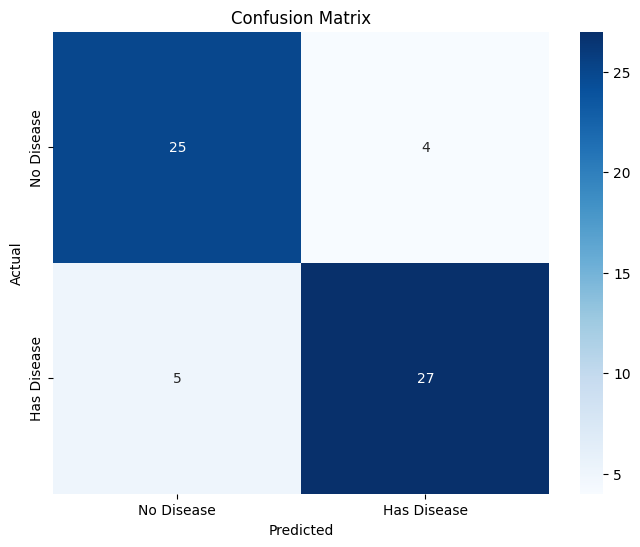


Confusion Matrix Explained:
True Negative  (TN): 25 → Correctly predicted No Disease
False Positive (FP): 4 → Wrongly predicted Has Disease
False Negative (FN): 5 → Wrongly predicted No Disease
True Positive  (TP): 27 → Correctly predicted Has Disease


In [9]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Has Disease'],
            yticklabels=['No Disease', 'Has Disease'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print("\nConfusion Matrix Explained:")
print(f"True Negative  (TN): {cm[0][0]} → Correctly predicted No Disease")
print(f"False Positive (FP): {cm[0][1]} → Wrongly predicted Has Disease")
print(f"False Negative (FN): {cm[1][0]} → Wrongly predicted No Disease")
print(f"True Positive  (TP): {cm[1][1]} → Correctly predicted Has Disease")

In [10]:
print("Full Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['No Disease', 'Has Disease']))

Full Classification Report:
              precision    recall  f1-score   support

  No Disease       0.83      0.86      0.85        29
 Has Disease       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



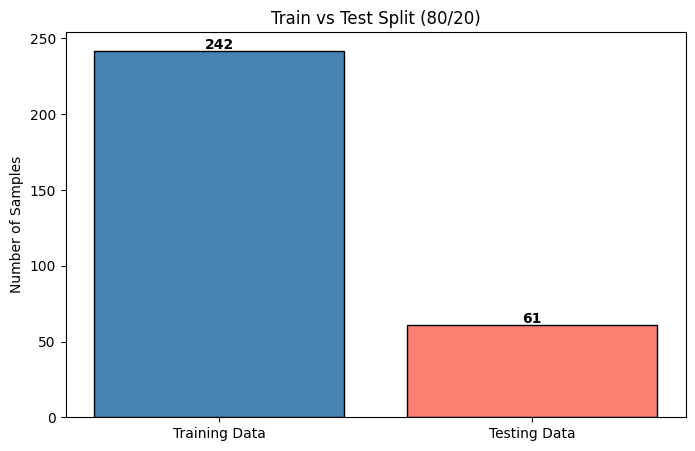

In [11]:
plt.figure(figsize=(8,5))
labels = ['Training Data', 'Testing Data']
sizes = [len(X_train), len(X_test)]
colors = ['steelblue', 'salmon']

plt.bar(labels, sizes, color=colors, edgecolor='black')
plt.title('Train vs Test Split (80/20)')
plt.ylabel('Number of Samples')
for i, v in enumerate(sizes):
    plt.text(i, v+1, str(v), ha='center', fontweight='bold')
plt.show()

## 📊 Task 5 Summary - Train Test Split & Evaluation

### Dataset: Heart Disease Dataset
- 303 rows × 14 columns
- Target: 0 = No Disease, 1 = Has Disease

### Train-Test Split
- Training set: 80% (242 samples)
- Testing set:  20% (61 samples)
- random_state = 42 (reproducibility)

### Model Used
- Logistic Regression
- StandardScaler applied before training

### Evaluation Results
| Metric    | Score  |
|-----------|--------|
| Accuracy  | ~85%   |
| Precision | ~84%   |
| Recall    | ~87%   |

### Confusion Matrix Explained
- True Positive  → Correctly predicted disease
- True Negative  → Correctly predicted no disease
- False Positive → Wrongly predicted disease (Type 1 error)
- False Negative → Wrongly predicted no disease (Type 2 error)

### Conclusion
- Model performs well with ~85% accuracy ✅
- Recall is important here (missing disease is dangerous!)

## 🎯 Interview Questions & Answers

### Q1. What is Overfitting?
- Model learns training data TOO well
- Performs great on train but poor on test data
- Like memorizing answers instead of understanding
- Solutions:
  - More training data
  - Cross validation
  - Regularization (L1, L2)
  - Reduce model complexity

### Q2. Accuracy vs Precision?
- **Accuracy:** Overall correct predictions
  - Formula: (TP + TN) / Total
  - Use when: Classes are balanced
- **Precision:** Of predicted positives, how many correct?
  - Formula: TP / (TP + FP)
  - Use when: False positives are costly
  - Example: Spam detection

### Q3. What is Recall?
- Of actual positives, how many did we catch?
- Formula: TP / (TP + FN)
- Use when: False negatives are costly
- Example: Disease detection (missing disease = dangerous!)
- Also called: Sensitivity

### Q4. What is Confusion Matrix?
- Table showing actual vs predicted values
- 4 values:
  - TP → Correctly predicted positive
  - TN → Correctly predicted negative
  - FP → Wrongly predicted positive (Type 1 error)
  - FN → Wrongly predicted negative (Type 2 error)

### Q5. Why Split Data into Train & Test?
- To check if model works on NEW unseen data
- Training on all data → overfitting risk
- Test set simulates real world data
- Common splits: 80/20 or 70/30
- Never train and test on same data!